# Working with Text Data

## Agenda

**Working with text data**

- Representing text as data
- Reading SMS data
- Vectorizing SMS data
- Examining the tokens and their counts
- Bonus: Calculating the "spamminess" of each token

### Libraries

In [18]:
import numpy as np# is for mathematical calculations
import pandas as pd # to deal with tabulear data
import requests # use to send html requests
import csv
import missingno as msno # used to find missing values
###########################
# visualizations
import plotly
import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
############################
# used to ignore the warnings
import warnings
warnings.filterwarnings('ignore')

######## Machine learning
from sklearn.model_selection import train_test_split # split the data
from nltk.corpus import stopwords #  to remove the common stopwords from english langauge
from nltk.stem.porter import PorterStemmer # for stemming
from sklearn.feature_extraction.text import CountVectorizer
import nltk
import string
from wordcloud import WordCloud, STOPWORDS
import re
eng_stopwords = set(stopwords.words("english"))
from textblob import TextBlob
from nltk.stem import WordNetLemmatizer,SnowballStemmer
from nltk.tokenize import RegexpTokenizer
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer, HashingVectorizer, TfidfTransformer
from sklearn.naive_bayes import MultinomialNB,GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report,confusion_matrix,roc_auc_score,roc_curve
from xgboost import XGBClassifier
from sklearn import metrics

### Data Load 

In [19]:
sms = pd.read_csv('sms.csv')

In [20]:
sms.head(10)

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
5,spam,FreeMsg Hey there darling it's been 3 week's n...
6,ham,Even my brother is not like to speak with me. ...
7,ham,As per your request 'Melle Melle (Oru Minnamin...
8,spam,WINNER!! As a valued network customer you have...
9,spam,Had your mobile 11 months or more? U R entitle...


In [21]:
sms.shape

(5572, 2)

In [22]:
sms['message'][2]

"Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's"

In [23]:
sms.label.value_counts()/sum(sms.label.value_counts()) * 100

label
ham     86.593683
spam    13.406317
Name: count, dtype: float64

In [27]:
fig = px.pie(sms, values=sms.label.value_counts(), names=['spam','ham'], color_discrete_sequence=px.colors.sequential.RdBu,
            title = 'Class Distribution of Y-variable')

In [28]:
# convert label to a numeric variable
sms['label'] = sms.label.map({'ham':0, 'spam':1})

In [29]:
sms.head()

,label,message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


<Axes: >

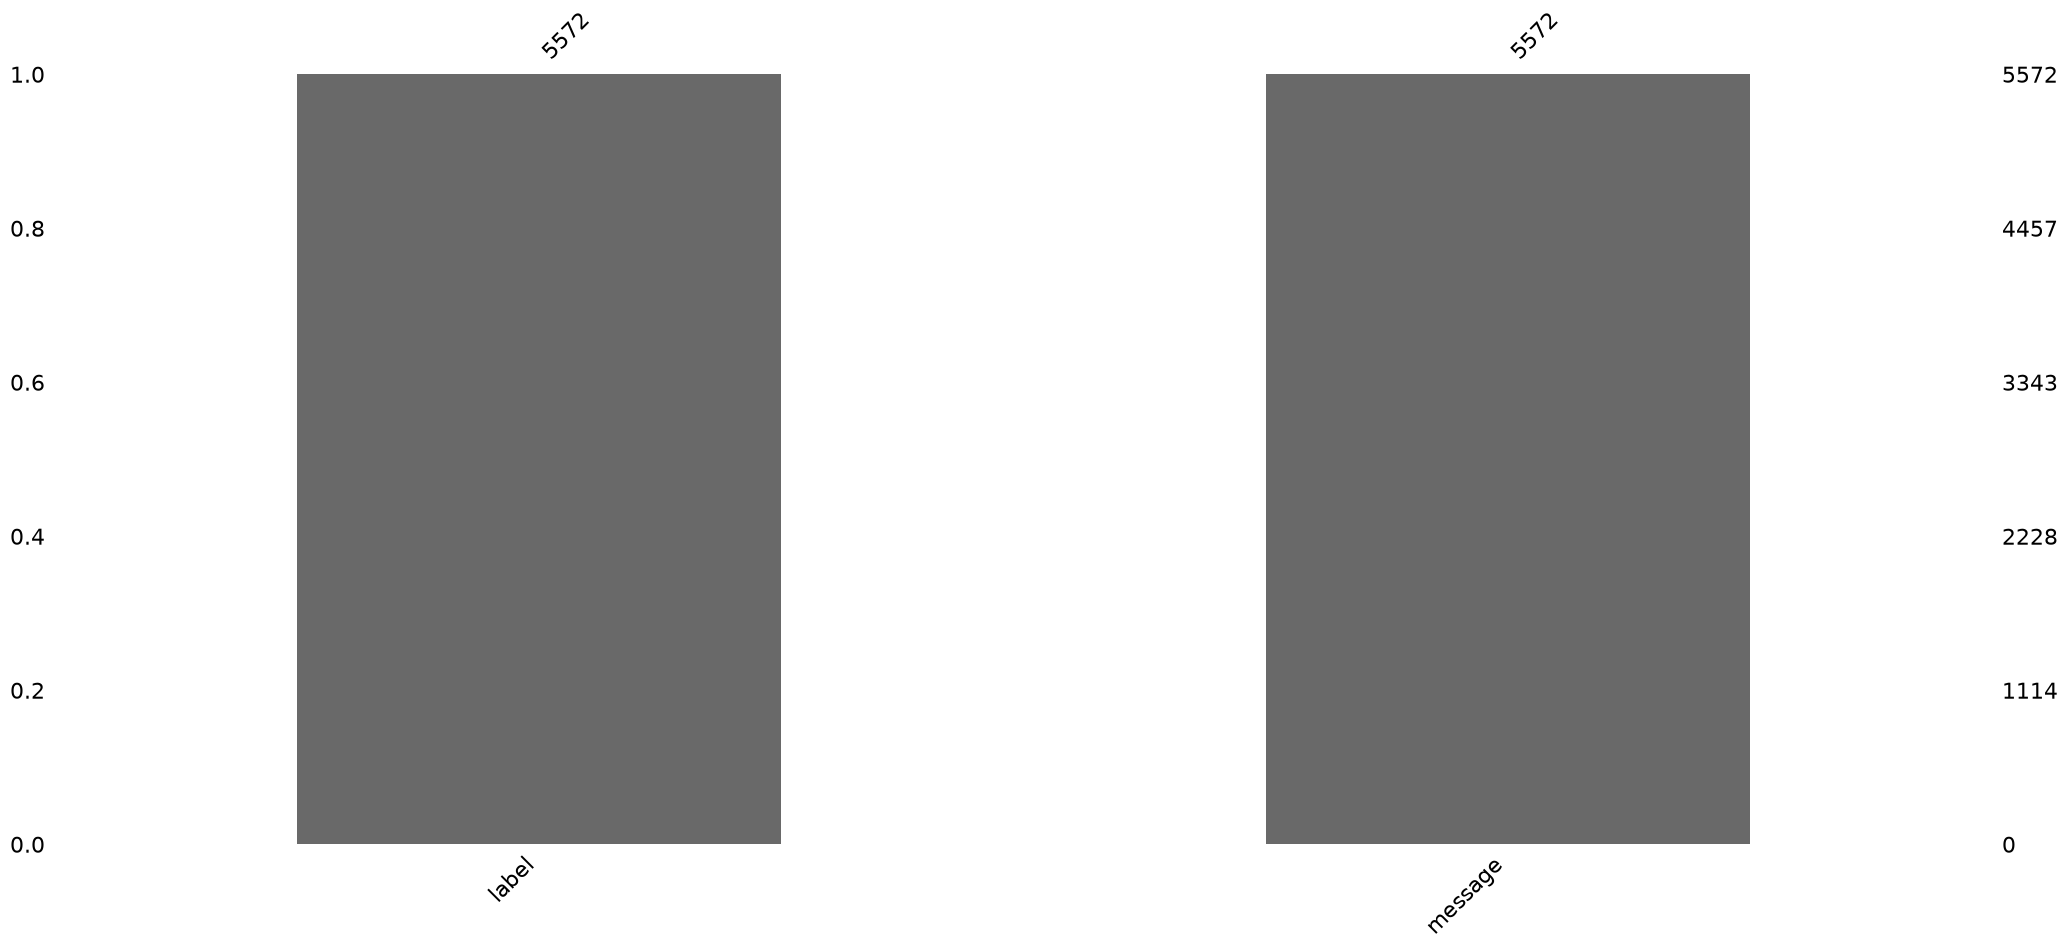

In [30]:
msno.bar(sms)

In [31]:
sms.duplicated().sum()

np.int64(403)

In [12]:
sms.drop_duplicates(inplace=True)

* The Y-variable is highly imbalanced and needs to be tackeled.
* There are no missing value in the dataset.
* There are 403 duplicates and that are removed from the dataset

### Converting Text To Vectors

> Case Conversion

In [13]:
sms['message'] = sms['message'].astype(str)
sms['message'] = sms['message'].apply(lambda x:x.lower())

> Data Cleaning Via Regex

In [14]:
def pre_process_text(x):
    x = x.strip()
    x = re.sub(r' +', ' ', x)
    x = re.sub(r"[-()\"#/@;:{}`+=~|.!?,'0-9]", "", x)
    return(x)

In [15]:
print('Before Cleaning')
print(sms['message'][0])

Before Cleaning
go until jurong point, crazy.. available only in bugis n great world la e buffet... cine there got amore wat...


In [16]:
sms['message'] = sms['message'].apply(pre_process_text)

In [17]:
print('After Cleaning')
print(sms['message'][0])

After Cleaning
go until jurong point crazy available only in bugis n great world la e buffet cine there got amore wat


> Stopwords Removal

In [18]:
sms['message'] = sms['message'].apply(lambda x: ' '.join([word for word in x.split() if word not in (eng_stopwords)]))

> Stemming and Lemmatization

In [19]:
def stemandlem(text):
    stemmer=SnowballStemmer('english')
    return stemmer.stem(WordNetLemmatizer().lemmatize(text, pos='v'))

In [20]:
sms['message'] = sms['message'].apply(lambda x:stemandlem(x))

In [21]:
sms

,label,message
0,0,go jurong point crazy available bugis n great ...
1,0,ok lar joking wif u oni
2,1,free entry wkly comp win fa cup final tkts st ...
3,0,u dun say early hor u c already say
4,0,nah dont think goes usf lives around though
...,...,...
5567,1,nd time tried contact u u £ pound prize claim ...
5568,0,ü b going esplanade fr hom
5569,0,pity * mood soany suggest
5570,0,guy bitching acted like id interested buying s...


In [22]:
sms.to_excel('cleaned1.xlsx',columns = ['label','message'])

### Text Visualization 

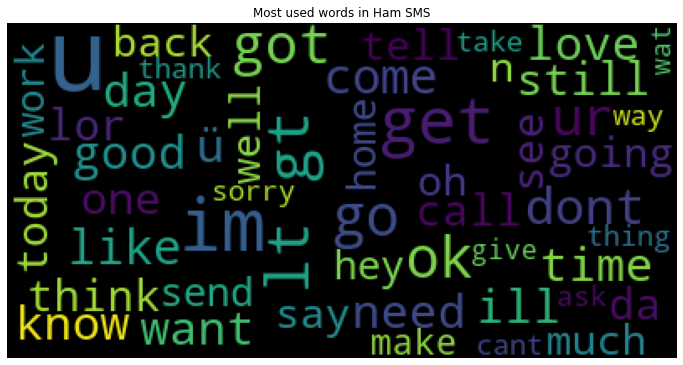

In [23]:
from wordcloud import WordCloud

T1=' '.join(sms.loc[sms.label==0].message.astype('str'))

wordcloud = WordCloud(max_words=50,stopwords=[],max_font_size=60,background_color='black').generate(T1)
plt.figure(figsize=(12,10))
# plot wordcloud in matplotlib
plt.imshow(wordcloud)
plt.axis("off")
plt.title('Most used words in Ham SMS')
plt.show()

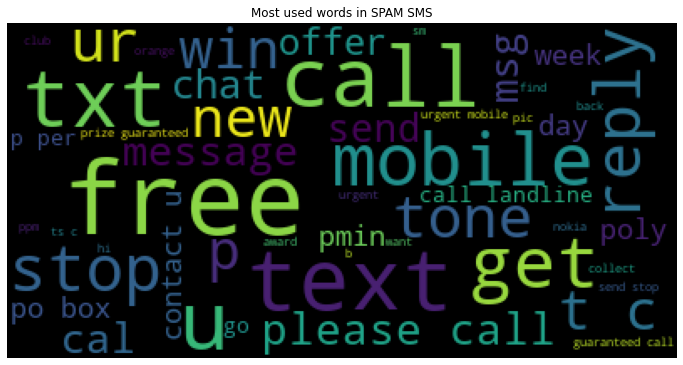

In [24]:
from wordcloud import WordCloud

T1=' '.join(sms.loc[sms.label==1].message.astype('str'))

wordcloud = WordCloud(max_words=50,stopwords=[],max_font_size=60,background_color='black').generate(T1)
plt.figure(figsize=(12,10))
# plot wordcloud in matplotlib
plt.imshow(wordcloud)
plt.axis("off")
plt.title('Most used words in SPAM SMS')
plt.show()

### Data Split 

In [25]:
# define X and y
X = sms.message
y = sms.label

In [26]:
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.5, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.7, random_state=42)

In [27]:
print('Shape of Training Dataset')
print(X_train.shape)
print(y_train.shape)

Shape of Training Dataset
(2584,)
(2584,)


In [28]:
print('Shape of Testing Dataset')
print(X_test.shape)
print(y_test.shape)

Shape of Testing Dataset
(1810,)
(1810,)


In [29]:
print('Shape of Validation Dataset')
print(X_val.shape)
print(y_val.shape)

Shape of Validation Dataset
(775,)
(775,)


### Text Vectorization 

In [30]:
count_vect = CountVectorizer(analyzer='word', token_pattern=r'\w{1,}', ngram_range=(1, 2))
xtrain_count_sms = count_vect.fit_transform(X_train)

tfidf_transformer = TfidfTransformer()
X_train_tfidf_sms = tfidf_transformer.fit_transform(xtrain_count_sms)
xtest_count_sms = count_vect.transform(X_test)
xval_count_sms = count_vect.transform(X_val)

X_test_tfidf_sms = tfidf_transformer.transform(xtest_count_sms)
X_val_tfidf_sms = tfidf_transformer.transform(xval_count_sms)

### Modeling 

### Logistic Regression With CountVectorizer

In [31]:
logreg = LogisticRegression()
logreg.fit(xtrain_count_sms, y_train)

LogisticRegression()

In [32]:
lr_valid_pred = logreg.predict(xval_count_sms)

In [33]:
print("Model Performance")
print("Validation Dataset")
print("Accuracy : ", metrics.accuracy_score(y_val, lr_valid_pred).round(3))
print(classification_report(y_val, lr_valid_pred))
lr_valid = metrics.accuracy_score(y_val, lr_valid_pred)

Model Performance
Validation Dataset
Accuracy :  0.974
              precision    recall  f1-score   support

           0       0.97      1.00      0.99       684
           1       1.00      0.78      0.88        91

    accuracy                           0.97       775
   macro avg       0.99      0.89      0.93       775
weighted avg       0.97      0.97      0.97       775



In [34]:
pred_lg_cnt_sms = logreg.predict(xtest_count_sms)
sms_logit_cnt = accuracy_score(y_test, pred_lg_cnt_sms).round(3)
print(" Testing Accuracy:",accuracy_score(y_test, pred_lg_cnt_sms).round(3))
sms_logit_cnt_auc = roc_auc_score(y_test, pred_lg_cnt_sms).round(3)
print("ROC-AUC Score: ",sms_logit_cnt_auc)
print(classification_report(y_test, pred_lg_cnt_sms))

 Testing Accuracy: 0.97
ROC-AUC Score:  0.89
              precision    recall  f1-score   support

           0       0.97      1.00      0.98      1571
           1       0.98      0.78      0.87       239

    accuracy                           0.97      1810
   macro avg       0.98      0.89      0.93      1810
weighted avg       0.97      0.97      0.97      1810



Text(0.5, 1.0, 'Logistic Regression Countvectorizer Confusion Matrix')

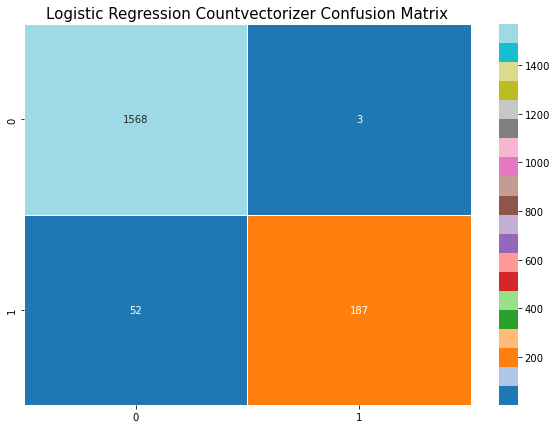

In [35]:
cm = confusion_matrix(y_test, pred_lg_cnt_sms)

plt.figure(figsize = (10,7))
sns.heatmap(cm, annot=True,linewidth = 0.5 , cmap = 'tab20' , fmt='d')
plt.title('Logistic Regression Countvectorizer Confusion Matrix', size=15)

### Logistic Regression With TF-IDF

In [36]:
logreg = LogisticRegression()
logreg.fit(X_train_tfidf_sms, y_train)

LogisticRegression()

In [37]:
lr_valid_pred = logreg.predict(X_val_tfidf_sms)

In [38]:
print("Model Performance")
print("Validation Dataset")
print("Accuracy : ", metrics.accuracy_score(y_val, lr_valid_pred).round(3))
print(classification_report(y_val, lr_valid_pred))
lr_valid = metrics.accuracy_score(y_val, lr_valid_pred)

Model Performance
Validation Dataset
Accuracy :  0.946
              precision    recall  f1-score   support

           0       0.94      1.00      0.97       684
           1       1.00      0.54      0.70        91

    accuracy                           0.95       775
   macro avg       0.97      0.77      0.84       775
weighted avg       0.95      0.95      0.94       775



In [39]:
pred_lg_tfidf_sms = logreg.predict(X_test_tfidf_sms)
sms_logit_tfidf = accuracy_score(y_test, pred_lg_tfidf_sms).round(3)
print("Accuracy:",accuracy_score(y_test, pred_lg_tfidf_sms).round(3))
sms_logit_tfidf_auc = roc_auc_score(y_test, pred_lg_tfidf_sms).round(3)
print("ROC-AUC Score: ",sms_logit_tfidf_auc)
print(classification_report(y_test, pred_lg_tfidf_sms))

Accuracy: 0.931
ROC-AUC Score:  0.744
              precision    recall  f1-score   support

           0       0.93      1.00      0.96      1571
           1       0.97      0.49      0.65       239

    accuracy                           0.93      1810
   macro avg       0.95      0.74      0.81      1810
weighted avg       0.93      0.93      0.92      1810



Text(0.5, 1.0, 'Logistic Regression TFIDF Confusion Matrix')

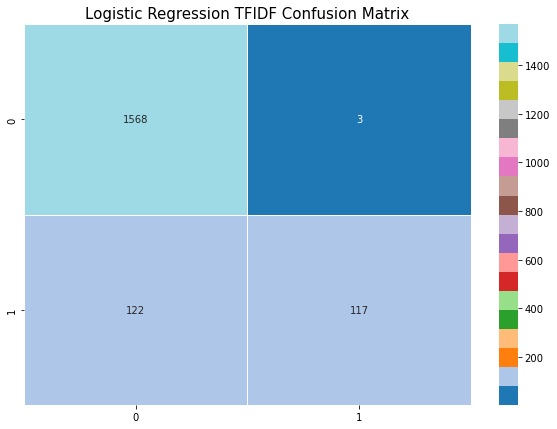

In [40]:
cm = confusion_matrix(y_test, pred_lg_tfidf_sms)

plt.figure(figsize = (10,7))
sns.heatmap(cm, annot=True,linewidth = 0.5 , cmap = 'tab20' , fmt='d')
plt.title('Logistic Regression TFIDF Confusion Matrix', size=15)

### XgBoost With Count-Vectorizer

In [41]:
xgb_estimator = XGBClassifier(n_estimators=200,
                         random_state = 42,
                        n_jobs=-1,
                        verbose=1)
xgb_estimator.fit(xtrain_count_sms, y_train)

[02:23:08] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-07593ffd91cd9da33-1\xgboost\xgboost-ci-windows\src\learner.cc:767: 
Parameters: { "verbose" } are not used.



XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, gpu_id=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              n_estimators=200, n_jobs=-1, num_parallel_tree=None,
              predictor=None, random_state=42, ...)

In [42]:
xgb_valid_pred = xgb_estimator.predict(xval_count_sms)

In [43]:
print("Model Performance")
print("Validation Dataset")
print("Accuracy : ", metrics.accuracy_score(y_val, xgb_valid_pred).round(3))
print(classification_report(y_val, xgb_valid_pred))
lr_valid = metrics.accuracy_score(y_val, xgb_valid_pred)

Model Performance
Validation Dataset
Accuracy :  0.968
              precision    recall  f1-score   support

           0       0.98      0.99      0.98       684
           1       0.90      0.81      0.86        91

    accuracy                           0.97       775
   macro avg       0.94      0.90      0.92       775
weighted avg       0.97      0.97      0.97       775



In [44]:
pred_xgb_cnt_sms = xgb_estimator.predict(xtest_count_sms)
sms_xgb_cnt = accuracy_score(y_test, pred_xgb_cnt_sms).round(3)
print("Accuracy:",accuracy_score(y_test, pred_xgb_cnt_sms).round(3))
sms_xgb_cnt_auc = roc_auc_score(y_test, pred_xgb_cnt_sms).round(3)
print("ROC-AUC Score: ",sms_xgb_cnt_auc)
print(classification_report(y_test, pred_xgb_cnt_sms))

Accuracy: 0.967
ROC-AUC Score:  0.905
              precision    recall  f1-score   support

           0       0.97      0.99      0.98      1571
           1       0.92      0.82      0.87       239

    accuracy                           0.97      1810
   macro avg       0.95      0.90      0.93      1810
weighted avg       0.97      0.97      0.97      1810



Text(0.5, 1.0, 'XgBoost Countvectorizer Confusion Matrix ')

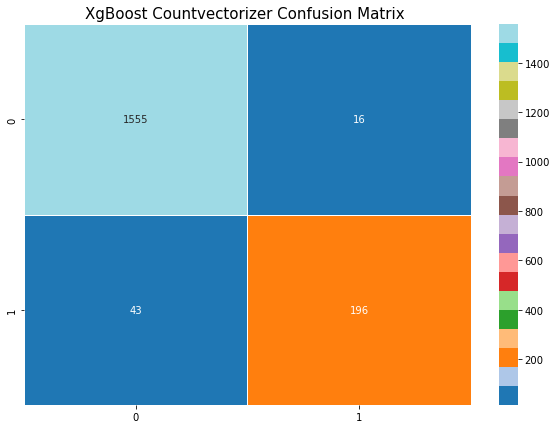

In [45]:
cm = confusion_matrix(y_test, pred_xgb_cnt_sms)

plt.figure(figsize = (10,7))
sns.heatmap(cm, annot=True,linewidth = 0.5 , cmap = 'tab20' , fmt='d')
plt.title('XgBoost Countvectorizer Confusion Matrix ', size=15)

### XgBoost With TF-IDF

In [46]:
xgb_estimator_sms_tfidf = XGBClassifier(n_estimators=200,
                         random_state = 42,
                        n_jobs=-1,
                        verbose=1)
xgb_estimator_sms_tfidf.fit(X_train_tfidf_sms, y_train)

[02:23:11] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-07593ffd91cd9da33-1\xgboost\xgboost-ci-windows\src\learner.cc:767: 
Parameters: { "verbose" } are not used.



XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, gpu_id=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              n_estimators=200, n_jobs=-1, num_parallel_tree=None,
              predictor=None, random_state=42, ...)

In [47]:
xgb_valid_pred_tf = xgb_estimator_sms_tfidf.predict(X_val_tfidf_sms)

In [48]:
print("Model Performance")
print("Validation Dataset")
print("Accuracy : ", metrics.accuracy_score(y_val, xgb_valid_pred_tf).round(3))
print(classification_report(y_val, xgb_valid_pred_tf))
lr_valid = metrics.accuracy_score(y_val, xgb_valid_pred_tf)

Model Performance
Validation Dataset
Accuracy :  0.959
              precision    recall  f1-score   support

           0       0.96      1.00      0.98       684
           1       0.98      0.66      0.79        91

    accuracy                           0.96       775
   macro avg       0.97      0.83      0.88       775
weighted avg       0.96      0.96      0.96       775



In [49]:
pred_xgb_tfidf_sms = xgb_estimator_sms_tfidf.predict(X_test_tfidf_sms)
sms_xgb_tfidf = accuracy_score(y_test, pred_xgb_tfidf_sms).round(3)
print("Accuracy:",accuracy_score(y_test, pred_xgb_tfidf_sms).round(3))
sms_xgb_tfidf_auc = roc_auc_score(y_test, pred_xgb_tfidf_sms).round(3)
print("ROC-AUC Score: ",sms_xgb_tfidf_auc)
print(classification_report(y_test, pred_xgb_tfidf_sms))

Accuracy: 0.952
ROC-AUC Score:  0.829
              precision    recall  f1-score   support

           0       0.95      1.00      0.97      1571
           1       0.96      0.66      0.78       239

    accuracy                           0.95      1810
   macro avg       0.96      0.83      0.88      1810
weighted avg       0.95      0.95      0.95      1810



Text(0.5, 1.0, 'XgBoost TFIDF Confusion Matrix')

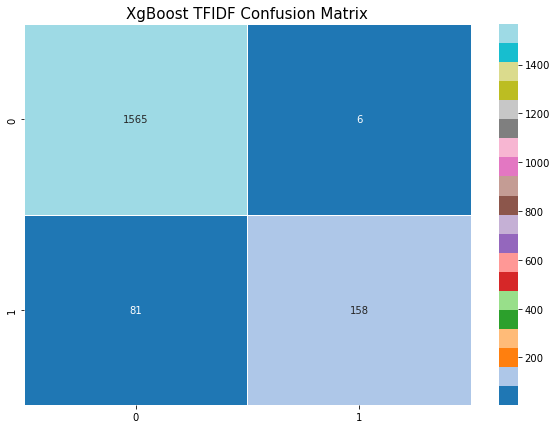

In [50]:
cm = confusion_matrix(y_test, pred_xgb_tfidf_sms)

plt.figure(figsize = (10,7))
sns.heatmap(cm, annot=True,linewidth = 0.5 , cmap = 'tab20' , fmt='d')
plt.title('XgBoost TFIDF Confusion Matrix', size=15)

### Decision Tree With Count-Vectorizer

In [51]:
dt = DecisionTreeClassifier()
dt.fit(xtrain_count_sms, y_train)

DecisionTreeClassifier()

In [52]:
dt_valid_pred = dt.predict(xval_count_sms)

In [53]:
print("Model Performance")
print("Validation Dataset")
print("Accuracy : ", metrics.accuracy_score(y_val, dt_valid_pred).round(3))
print(classification_report(y_val, dt_valid_pred))
dt_valid = metrics.accuracy_score(y_val, dt_valid_pred)

Model Performance
Validation Dataset
Accuracy :  0.961
              precision    recall  f1-score   support

           0       0.97      0.98      0.98       684
           1       0.86      0.80      0.83        91

    accuracy                           0.96       775
   macro avg       0.92      0.89      0.90       775
weighted avg       0.96      0.96      0.96       775



In [54]:
pred_dt_cnt_sms = dt.predict(xtest_count_sms)
sms_dt_cnt = accuracy_score(y_test, pred_dt_cnt_sms).round(3)
print("Accuracy:",accuracy_score(y_test, pred_dt_cnt_sms).round(3))
sms_dt_cnt_auc = roc_auc_score(y_test, pred_dt_cnt_sms).round(3)
print("ROC-AUC Score: ",sms_dt_cnt_auc)
print(classification_report(y_test, pred_dt_cnt_sms))

Accuracy: 0.95
ROC-AUC Score:  0.849
              precision    recall  f1-score   support

           0       0.96      0.99      0.97      1571
           1       0.89      0.71      0.79       239

    accuracy                           0.95      1810
   macro avg       0.92      0.85      0.88      1810
weighted avg       0.95      0.95      0.95      1810



Text(0.5, 1.0, 'Decison Tree Countvectorizer Confusion Matrix ')

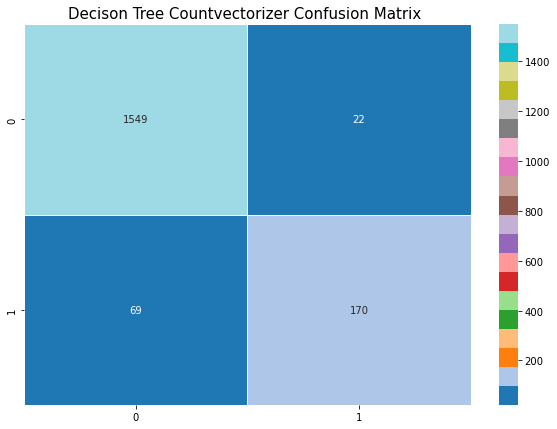

In [55]:
cm = confusion_matrix(y_test, pred_dt_cnt_sms)

plt.figure(figsize = (10,7))
sns.heatmap(cm, annot=True,linewidth = 0.5 , cmap = 'tab20' , fmt='d')
plt.title('Decison Tree Countvectorizer Confusion Matrix ', size=15)

### Decision Tree With TF-IDF

In [56]:
dt_tfidf = DecisionTreeClassifier()
dt_tfidf.fit(X_train_tfidf_sms, y_train)

DecisionTreeClassifier()

In [57]:
dt_valid_pred_tf = dt_tfidf.predict(X_val_tfidf_sms)

In [58]:
print("Model Performance")
print("Validation Dataset")
print("Accuracy : ", metrics.accuracy_score(y_val, dt_valid_pred_tf).round(3))
print(classification_report(y_val, dt_valid_pred_tf))
lr_valid = metrics.accuracy_score(y_val, dt_valid_pred_tf)

Model Performance
Validation Dataset
Accuracy :  0.948
              precision    recall  f1-score   support

           0       0.96      0.98      0.97       684
           1       0.85      0.68      0.76        91

    accuracy                           0.95       775
   macro avg       0.90      0.83      0.86       775
weighted avg       0.95      0.95      0.95       775



In [59]:
pred_dt_tfidf_sms = dt_tfidf.predict(X_test_tfidf_sms)
sms_dt_tfidf = accuracy_score(y_test, pred_dt_tfidf_sms).round(3)
print("Accuracy:",accuracy_score(y_test, pred_dt_tfidf_sms).round(3))
sms_dt_tfidf_auc = roc_auc_score(y_test, pred_dt_tfidf_sms).round(3)
print("ROC-AUC Score: ",sms_dt_tfidf_auc)
print(classification_report(y_test, pred_dt_tfidf_sms))

Accuracy: 0.948
ROC-AUC Score:  0.855
              precision    recall  f1-score   support

           0       0.96      0.98      0.97      1571
           1       0.86      0.73      0.79       239

    accuracy                           0.95      1810
   macro avg       0.91      0.85      0.88      1810
weighted avg       0.95      0.95      0.95      1810



Text(0.5, 1.0, 'Decison Tree TF-IDF Confusion Matrix ')

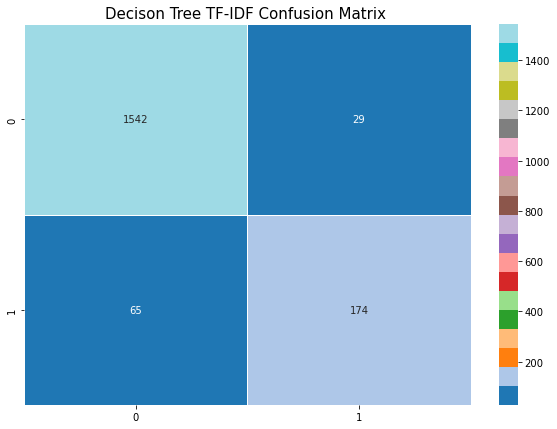

In [60]:
cm = confusion_matrix(y_test, pred_dt_tfidf_sms)

plt.figure(figsize = (10,7))
sns.heatmap(cm, annot=True,linewidth = 0.5 , cmap = 'tab20' , fmt='d')
plt.title('Decison Tree TF-IDF Confusion Matrix ', size=15)

### Naive Bayes With Count-Vectorizer

In [62]:
nb = MultinomialNB()
nb.fit(xtrain_count_sms, y_train)

MultinomialNB()

In [63]:
nb_valid_pred = nb.predict(xval_count_sms)

In [65]:
print("Model Performance")
print("Validation Dataset")
print("Accuracy : ", metrics.accuracy_score(y_val, nb_valid_pred).round(3))
print(classification_report(y_val, nb_valid_pred))
nb_valid = metrics.accuracy_score(y_val, nb_valid_pred)

Model Performance
Validation Dataset
Accuracy :  0.981
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       684
           1       0.95      0.88      0.91        91

    accuracy                           0.98       775
   macro avg       0.97      0.94      0.95       775
weighted avg       0.98      0.98      0.98       775



In [66]:
pred_nb_cnt_sms = nb.predict(xtest_count_sms)
sms_nb_cnt = accuracy_score(y_test, pred_nb_cnt_sms).round(3)
print("Accuracy:",accuracy_score(y_test, pred_nb_cnt_sms).round(3))
sms_nb_cnt_auc = roc_auc_score(y_test, pred_nb_cnt_sms).round(3)
print("ROC-AUC Score: ",sms_nb_cnt_auc)
print(classification_report(y_test, pred_nb_cnt_sms))

Accuracy: 0.983
ROC-AUC Score:  0.944
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1571
           1       0.98      0.89      0.93       239

    accuracy                           0.98      1810
   macro avg       0.98      0.94      0.96      1810
weighted avg       0.98      0.98      0.98      1810



Text(0.5, 1.0, 'Naive Bayes Countvectorizer Confusion Matrix ')

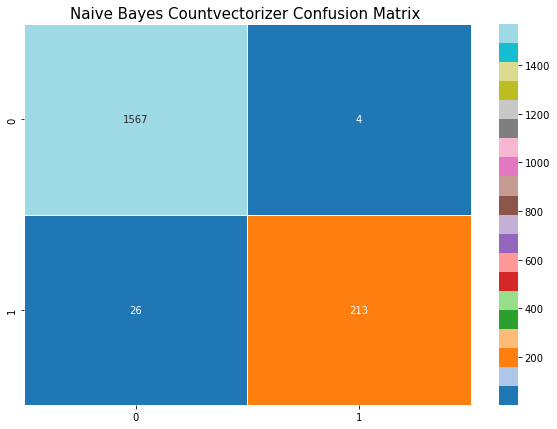

In [67]:
cm = confusion_matrix(y_test, pred_nb_cnt_sms)

plt.figure(figsize = (10,7))
sns.heatmap(cm, annot=True,linewidth = 0.5 , cmap = 'tab20' , fmt='d')
plt.title('Naive Bayes Countvectorizer Confusion Matrix ', size=15)

### Naive Bayes With TF-IDF

In [70]:
nb_tfidf = MultinomialNB()
nb_tfidf.fit(X_train_tfidf_sms, y_train)

MultinomialNB()

In [71]:
nb_valid_pred_tf = nb_tfidf.predict(X_val_tfidf_sms)

In [72]:
print("Model Performance")
print("Validation Dataset")
print("Accuracy : ", metrics.accuracy_score(y_val, nb_valid_pred_tf).round(3))
print(classification_report(y_val, nb_valid_pred_tf))
nb_valid = metrics.accuracy_score(y_val, nb_valid_pred_tf)

Model Performance
Validation Dataset
Accuracy :  0.945
              precision    recall  f1-score   support

           0       0.94      1.00      0.97       684
           1       1.00      0.53      0.69        91

    accuracy                           0.94       775
   macro avg       0.97      0.76      0.83       775
weighted avg       0.95      0.94      0.94       775



In [73]:
pred_nb_tfidf_sms = nb_tfidf.predict(X_test_tfidf_sms)
sms_nb_tfidf = accuracy_score(y_test, pred_nb_tfidf_sms).round(3)
print("Accuracy:",accuracy_score(y_test, pred_nb_tfidf_sms).round(3))
sms_nb_tfidf_auc = roc_auc_score(y_test, pred_nb_tfidf_sms).round(3)
print("ROC-AUC Score: ",sms_nb_tfidf_auc)
print(classification_report(y_test, pred_nb_tfidf_sms))

Accuracy: 0.931
ROC-AUC Score:  0.738
              precision    recall  f1-score   support

           0       0.93      1.00      0.96      1571
           1       1.00      0.48      0.65       239

    accuracy                           0.93      1810
   macro avg       0.96      0.74      0.80      1810
weighted avg       0.94      0.93      0.92      1810



Text(0.5, 1.0, 'Naive Bayes TF-IDF Confusion Matrix ')

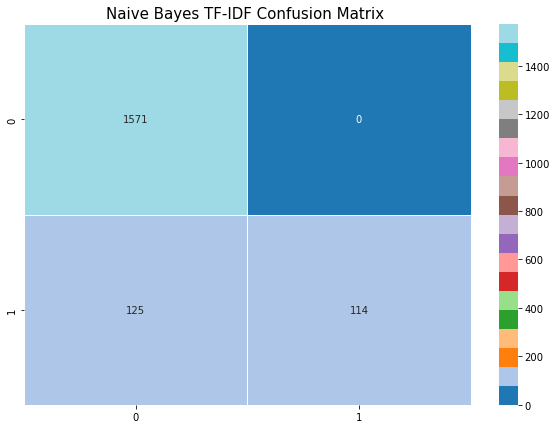

In [74]:
cm = confusion_matrix(y_test, pred_nb_tfidf_sms)

plt.figure(figsize = (10,7))
sns.heatmap(cm, annot=True,linewidth = 0.5 , cmap = 'tab20' , fmt='d')
plt.title('Naive Bayes TF-IDF Confusion Matrix ', size=15)

In [75]:
SMS_df = {'Classifiers':['Logistic_Regression_CountVectorizer','Logistic_Regression_TF-IDF',
                     'XGBoost_CountVectorizer','XGBoost_TF-IDF',
                          'Decision_Tree_CountVectorizer','Decision_Tree_TF-IDF','Naive_Bayes_CountVectorizer',
                        'Naive_Bayes_TF-IDF'],
                       'Accuracy': [sms_logit_cnt,sms_logit_tfidf,sms_xgb_cnt,sms_xgb_tfidf,sms_dt_cnt,sms_dt_tfidf,sms_nb_cnt,sms_nb_tfidf]}

In [76]:
SMS_df = pd.DataFrame(SMS_df)
SMS_df

,Classifiers,Accuracy
0,Logistic_Regression_CountVectorizer,0.970
1,Logistic_Regression_TF-IDF,0.931
2,XGBoost_CountVectorizer,0.967
3,XGBoost_TF-IDF,0.952
4,Decision_Tree_CountVectorizer,0.950
5,Decision_Tree_TF-IDF,0.948
6,Naive_Bayes_CountVectorizer,0.983
7,Naive_Bayes_TF-IDF,0.931


In [77]:
import plotly.express as px
fig = px.bar(SMS_df, x='Classifiers', y='Accuracy',title='Accuracy Chart')
fig.show()

In [78]:
SMS_df_auc = {'Classifiers':['Logistic_Regression_CountVectorizer','Logistic_Regression_TF-IDF',
                     'XGBoost_CountVectorizer','XGBoost_TF-IDF',
                          'Decision_Tree_CountVectorizer','Decision_Tree_TF-IDF','Naive_Bayes_CountVectorizer',
                        'Naive_Bayes_TF-IDF'],
                       'AUC': [sms_logit_cnt_auc,sms_logit_tfidf_auc,sms_xgb_cnt_auc,sms_xgb_tfidf_auc,sms_dt_cnt_auc,sms_dt_tfidf_auc,sms_nb_cnt_auc,sms_nb_tfidf_auc]}

In [79]:
SMS_df_auc = pd.DataFrame(SMS_df_auc)
SMS_df_auc

,Classifiers,AUC
0,Logistic_Regression_CountVectorizer,0.890
1,Logistic_Regression_TF-IDF,0.744
2,XGBoost_CountVectorizer,0.905
3,XGBoost_TF-IDF,0.829
4,Decision_Tree_CountVectorizer,0.849
5,Decision_Tree_TF-IDF,0.855
6,Naive_Bayes_CountVectorizer,0.944
7,Naive_Bayes_TF-IDF,0.738


In [80]:
import plotly.express as px
fig = px.bar(SMS_df_auc, x='Classifiers', y='AUC',title='AUC Score')
fig.show()